# PartUV × 纹理密度：五步管线

| 步骤 | 做什么 | 产出 |
|---|---|---|
| **STEP 1** | 加载 mesh（带纹理则同时读入原贴图） | 输入模型 3D 预览 |
| **STEP 2** | PartUV 分解 + 展开 + 打包 | **UV map**（chart 布局） |
| **STEP 3** | 按 PartUV 的映射把原纹理烘进新 UV | **展开的纹理贴图**（单图集） |
| **STEP 4** | 白模几何 + 整体纹理内容频率 | **纹理密度需求分布** $w(f)$ |
| **STEP 5** | 以密度为调整信息重排 UV 布局 | 最终 UV + 贴图：**每纹素承载的信息量均匀** |

> STEP 5 的"密度均匀"指 **L2 意义（信息量均匀，人口地图）**：细节多的表面拿更多纹素，
> 几何 TD 故意不均——这正是与 STEP 2/3（PartUV 原版=几何均匀）的对照点。
> 环境 conda `geomae`；数据 `code/data/`（选网格查 `CATALOG.md`）。

## 术语澄清：只有一种"密度"

全篇只有一个物理量——**纹理密度 $\mathrm{TD}(f)$**（每单位表面积分到的纹素数）。
**L1 / L2 / L3 不是三种密度，是同一个密度的三种分配政策**（课题内部速记，出处：`纹理密度/01-研究任务梳理.md`）：

| 记号 | 含义 | 世界地图类比 | 结果 |
|---|---|---|---|
| L1 均匀 | 处处一样（业界标准/验收底线） | 自然地理等积地图 | $\mathrm{TD}\approx$ 常数 |
| L2 内容感知 | 细节多处多给（研究主攻） | 人口 cartogram | $\mathrm{TD}\propto$ 内容权重 |
| L3 用户指定 | 美术按 part 填预算（交互接口） | 行政规划 | $\mathrm{TD}$ 由预算决定 |

递进关系：L2 中 $\gamma=0$ 即退化为 L1；L3 = 把 L2 的自动权重换成人填的数。
另外三个易混名词都**不是**密度：`cw(f)` 是需求信号、`scale` 是 chart 级的密度汇总、
CV/CV$_w$ 是均匀度的评价指标。

---

## 纹理密度公式速查（与代码变量一一对应）

**1. 逐面纹理密度 TD** —— 代码 `face_td()` / `td_pv` / `td_ours`【核心在用】

对三角形 $f$（3D 顶点 $v_0,v_1,v_2$，UV 顶点 $u_0,u_1,u_2$）：

$$A_{3D}(f)=\tfrac12\big\lVert(v_1-v_0)\times(v_2-v_0)\big\rVert,\qquad
A_{UV}(f)=\tfrac12\big\lvert(u_1-u_0)\times(u_2-u_0)\big\rvert$$

$$\mathrm{TD}(f)=R\cdot\sqrt{\frac{A_{UV}(f)}{A_{3D}(f)}}\qquad\text{（单位: px / 世界长度单位）}$$

$R$ 为图集分辨率（如 1024）。**开根号**是因为密度是线性量（px/cm），而面积是二次量。
本 notebook 的图表多用相对 TD（省略 $R$，只看分布形状）。

**2. chart 线性尺度**（理论依据：`layout_with_scales()` 每 chart 一个标量的合法性来源）

$$s_c=\sqrt{\frac{\sum_{f\in c}A_{UV}(f)}{\sum_{f\in c}A_{3D}(f)}}$$

PartUV 的失真界 $\tau$ 保证 chart 内部 $\mathrm{TD}(f)\approx s_c$（波动 $\lesssim\pm25\%$），
所以**控制整模型的密度分布 = 给每个 chart 定一个标量**。

**3. L1 均匀密度（uniform TD）** —— 布局目标 $A_{UV}\propto A_{3D}$

$$u'=u\cdot f_c,\qquad f_c=\sqrt{\frac{\sum_{f\in c}A_{3D}(f)}{\sum_{f\in c}A_{UV}(f)}}$$

缩放后所有 chart 共享同一 UV/3D 面积比，交给打包器（Blender `pack_islands`）
旋转/摆放/统一全局缩放——打包不改变相对尺度，密度分配原样保留。

**4. L2 内容感知密度** —— 代码 STEP4（`cw`→`z`→`q(td_mult)`→`w=q²`）+ STEP5 `layout_with_scales(w)`【核心在用】

$$z_f=\frac{\log(\varepsilon+cw)-\mathrm{med}_A\log(\varepsilon+cw)}{\mathrm{MAD}_A\log(\varepsilon+cw)},\qquad q_f=\mathrm{clip}\Big(\tfrac{e^{\beta\,\mathrm{clip}(z_f,\pm z_{max})}}{\sqrt{\mathrm{mean}_A(q^2)}},q_{min},q_{max}\Big)$$

$$D_c=\sum_{f\in c}A_{3D}(f)\,q_f^2,\qquad f_c=\sqrt{\frac{D_c}{\sum_{f\in c}A_{UV}(f)}}$$

⚠ **语义**（评审 §2）：$q$ 是线性 TD 倍率、$w=q^2$ 是**面积预算倍率**——$\beta$ 作用于 log 线性密度，$\beta=0$ 退化为 L1；预算归一 $\mathrm{mean}_A(q^2)=1$ 保证 L2 与 L1 严格同预算（纯重分配）。内容信号 $cw$ 当前为亮度 std baseline，路线：表面梯度 → 多尺度 Hessian → rate–distortion oracle（评审 §6–7）。

**5. 均匀度指标** —— 代码 `cvw()`（本 notebook 只用面积加权版；未加权 CV 仅作对照说明）

$$\mathrm{CV}=\frac{\sigma(\mathrm{TD})}{\mu(\mathrm{TD})},\qquad
\mathrm{CV}_w=\frac{1}{\mu_w}\sqrt{\frac{\sum_f A_{3D}(f)\,\big(\mathrm{TD}(f)-\mu_w\big)^2}{\sum_f A_{3D}(f)}}$$

**以面积加权的 $\mathrm{CV}_w$ 为主指标**——未加权 CV 会被大量微小三角形抬高
（案例：某网格逐面 CV=2.18 而 $\mathrm{CV}_w$=0.078，感知上其实均匀）。

**6. PartUV 的失真度量**（论文式 (3)(4)，PartUV 自算、我们只读取 `charts[i]["distortion"]`；它是第 2 条成立的原因）

$$\mathrm{stretch}(f)=\frac{A_{UV}(f)/A_{3D}(f)}{\sum_{f'\in c}A_{UV}(f')\,/\sum_{f'\in c}A_{3D}(f')},\qquad
\mathrm{dist}(c)=\frac{1}{|c|}\sum_{f\in c}\max\big(\mathrm{stretch}(f),\,\mathrm{stretch}(f)^{-1}\big)\;\le\;\tau$$

即"单面的面积比相对 chart 整体面积比的偏离"——这正是第 2 条里 chart 内 TD 近似恒定的依据
（注意实测个别 chart 会略超 $\tau$，见 07 文档附录）。

**7. 绝对密度锚定（px/cm → 推荐分辨率；生产用，本 notebook 的多图集附录用其推广版 $R_k\propto\sqrt{D_k/\text{fill}_k}$）**

$$R_{\text{need}}=R\cdot\frac{\mathrm{TD}_{\text{target}}}{\overline{\mathrm{TD}}_{@R}}\;\longrightarrow\;\text{取最近的 }2^n$$

⚠ `preprocess()` 会把 mesh 归一化（中心化+等比缩放），换算真实 px/cm 时必须乘回世界尺度。


## STEP 1 · 加载 mesh

mesh: objaverse_22b822c6520d4d49.glb  faces=14458  原始UV=有  纹理=1024x1024


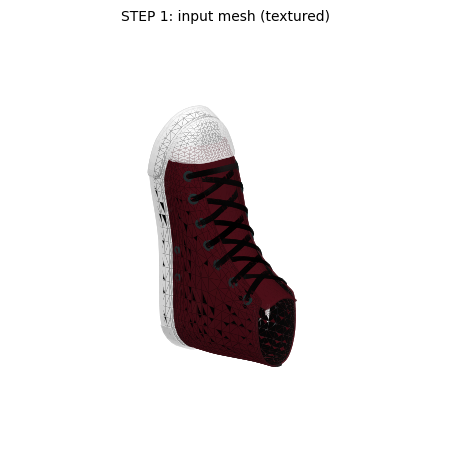

In [1]:
# ============ STEP 1: 配置 + 加载 mesh(带纹理则一并读入) ============
import os, glob, time, json, tempfile
import numpy as np
import trimesh
from scipy.spatial import cKDTree
import matplotlib.pyplot as plt
from matplotlib.collections import PolyCollection
from matplotlib.colors import Normalize
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

ROOT      = "/root/youjiaZhang/PartUV/code"
DATA      = f"{ROOT}/data"
OUT_ROOT  = f"{ROOT}/notebook/outputs"
CKPT      = "/root/zhaotianhao/PartField/model/model_objaverse.ckpt"
CFG_YAML  = f"{ROOT}/notebook/partuv_config.yaml"
THRESHOLD = 1.25                       # PartUV 失真阈值 τ
BETA, Z_MAX = 0.4, 2.5      # STEP4: q=exp(β·clip(z,±z_max)), β 作用于 log 线性TD; β=0 退化 L1
Q_MIN, Q_MAX = 0.5, 2.83    # 线性 TD 倍率界(对应面积预算 ×0.25 ~ ×8)

# ---- 选择测试网格(改这一行; STEP3-5 需要带纹理的 glb, 推荐查 CATALOG.md) ----
MESH = f"{DATA}/objaverse_22b822c6520d4d49.glb"    # 车轮: 螺栓/花纹 vs 平坦胎侧, 对比最清晰
# MESH = f"{DATA}/clock_2mat.glb"                  # 多材质+低利用率案例(自动合并/回收)
# MESH = f"{DATA}/objaverse_dd20303e82654cbd.glb"  # 细节高度集中(大片纯色), L2 极佳
# MESH = f"{DATA}/f45ac2100d2342fa8ab39d38d0f874ba.obj"  # 论文手雷(无纹理: 只有 STEP1-2)
assert os.path.exists(MESH) and os.path.exists(CKPT) and os.path.exists(CFG_YAML)

mesh_name = os.path.splitext(os.path.basename(MESH))[0]
OUT = f"{OUT_ROOT}/{mesh_name}/"
os.makedirs(OUT, exist_ok=True)

orig = trimesh.load(MESH, force="mesh")            # 多材质 scene 自动合并成单贴图+重映射UV
uv0 = getattr(orig.visual, "uv", None)
Vo, Fo = np.asarray(orig.vertices, float), np.asarray(orig.faces)
texA = None
try:
    _mat = orig.visual.material
    _img = getattr(_mat, "baseColorTexture", None) or getattr(_mat, "image", None)
    if _img is not None:
        texA = np.asarray(_img.convert("RGB"), dtype=float) / 255.0
except Exception:
    pass
HAS_TEX = texA is not None and uv0 is not None
print(f"mesh: {os.path.basename(MESH)}  faces={len(Fo)}  "
      f"原始UV={'有' if uv0 is not None else '无'}  "
      f"纹理={'%dx%d' % (texA.shape[1], texA.shape[0]) if texA is not None else '无'}")

def sample_bilinear(img, uvq):
    x = np.clip(uvq[:, 0], 0, 1) * (img.shape[1] - 1)
    y = np.clip(1 - uvq[:, 1], 0, 1) * (img.shape[0] - 1)
    x0 = np.floor(x).astype(int); y0 = np.floor(y).astype(int)
    x1 = np.minimum(x0 + 1, img.shape[1] - 1); y1 = np.minimum(y0 + 1, img.shape[0] - 1)
    fx = (x - x0)[:, None]; fy = (y - y0)[:, None]
    return (img[y0, x0] * (1 - fx) * (1 - fy) + img[y0, x1] * fx * (1 - fy)
            + img[y1, x0] * (1 - fx) * fy + img[y1, x1] * fx * fy)

def render_mesh3d(ax, V_, F_, col, title):
    tris = V_[F_]
    n = np.cross(tris[:, 1] - tris[:, 0], tris[:, 2] - tris[:, 0])
    n /= np.maximum(np.linalg.norm(n, axis=1, keepdims=True), 1e-12)
    shade = (0.7 + 0.3 * np.abs(n @ np.array([0.4, 0.5, 0.77])))[:, None]
    ax.add_collection3d(Poly3DCollection(tris, facecolors=np.clip(col * shade, 0, 1),
                                         edgecolors="none"))
    mn, mx = V_.min(0), V_.max(0); ct = (mn + mx) / 2; r = (mx - mn).max() / 2
    ax.set_xlim(ct[0]-r, ct[0]+r); ax.set_ylim(ct[1]-r, ct[1]+r); ax.set_zlim(ct[2]-r, ct[2]+r)
    ax.set_box_aspect((1, 1, 1)); ax.set_axis_off(); ax.view_init(elev=15, azim=45)
    ax.set_title(title, fontsize=10)

colA = np.full((len(Fo), 3), 0.62)
if HAS_TEX:
    colA = sample_bilinear(texA, np.asarray(uv0, float)[Fo].mean(axis=1))
fig = plt.figure(figsize=(5.6, 5.6))
render_mesh3d(fig.add_subplot(111, projection="3d"), Vo, Fo, colA,
              "STEP 1: input mesh" + (" (textured)" if HAS_TEX else " (white model)"))
plt.savefig(f"{OUT}/step1_mesh.png", dpi=110, bbox_inches="tight"); plt.show()

## STEP 2 · PartUV 得到 UV map

PartField 部件树 → 递归分解成 chart（失真 ≤ τ）→ ABF 摊平 → 打包（Blender `pack_islands`，chart 相对大小=纯 3D 面积，即官方隐式均匀 TD）。

In [2]:
# ============ STEP 2a: PartUV 分解展开 + chart<->面 对应 ============
import partuv
from partuv.preprocess_utils.partfield_official.run_PF import PFInferenceModel

t0 = time.time()
pf_model = PFInferenceModel(device="cuda", checkpoint_path=CKPT)
mesh, tree_file, tree_dict, _ = partuv.preprocess(
    MESH, pf_model, OUT, save_tree_file=False, save_processed_mesh=False,
    sample_on_faces=10, sample_batch_size=100_000, merge_vertices_epsilon=None)
V = np.asarray(mesh.vertices, dtype=np.float64)
F = np.asarray(mesh.faces,   dtype=np.int32)
final_parts, parts = partuv.pipeline_numpy(
    V=V, F=F, tree_dict=tree_dict, configPath=CFG_YAML, threshold=THRESHOLD)
print(f"PartUV: faces={len(F)} parts={len(parts)} "
      f"charts={sum(p.num_components for p in parts)}  ({time.time()-t0:.0f}s)")

mesh_scale = float(np.linalg.norm(V.max(0) - V.min(0)))

def face_normals(V_, F_):
    n = np.cross(V_[F_][:, 1] - V_[F_][:, 0], V_[F_][:, 2] - V_[F_][:, 0])
    return n / np.maximum(np.linalg.norm(n, axis=1, keepdims=True), 1e-16)

class FaceMatcher:
    """孪生面(双面重合几何)安全的面对应: 桶式一对一 + 法线判别 + kd 兜底.
    最近邻质心匹配会把重合孪生面折叠到同一索引(实测某资产 28.9% 孪生 ->
    coverage 虚报 5.79% 丢面); 本匹配器按质心 key 分桶, 候选>1 时选法线方向
    最一致者并弹出, 保证一对一."""
    def __init__(self, V_, F_, scale):
        from collections import defaultdict
        self.cent = V_[F_].mean(axis=1)
        self.nrm = face_normals(V_, F_)
        self.kd = cKDTree(self.cent)
        self.scale = scale
        self.buckets = defaultdict(list)
        for i, k in enumerate(map(tuple, np.round(self.cent / scale, 6))):
            self.buckets[k].append(i)
    def match(self, cV, cF):
        cents = cV[cF].mean(axis=1)
        nrms = face_normals(cV, cF)
        out = np.empty(len(cF), dtype=int)
        for j, k in enumerate(map(tuple, np.round(cents / self.scale, 6))):
            lst = self.buckets.get(k)
            if lst:
                if len(lst) == 1:
                    out[j] = lst.pop()
                else:
                    dots = [float(self.nrm[i] @ nrms[j]) for i in lst]
                    out[j] = lst.pop(int(np.argmax(dots)))
            else:
                out[j] = int(self.kd.query(cents[j][None])[1][0])
        return out

fm_proc = FaceMatcher(V, F, mesh_scale)

def tri_area_2d(uv):
    e1, e2 = uv[:, 1] - uv[:, 0], uv[:, 2] - uv[:, 0]
    return 0.5 * np.abs(e1[:, 0] * e2[:, 1] - e1[:, 1] * e2[:, 0])

def tri_area_3d(v):
    return 0.5 * np.linalg.norm(np.cross(v[:, 1] - v[:, 0], v[:, 2] - v[:, 0]), axis=1)

charts = []
face_part = np.full(len(F), -1); face_chart = np.full(len(F), -1)
mismatch = 0
for pi, p in enumerate(parts):
    for c in p.components:
        cV, cF, cUV = np.asarray(c.V), np.asarray(c.F), np.asarray(c.UV)
        gidx = fm_proc.match(cV, cF)
        d = np.linalg.norm(cV[cF].mean(axis=1) - fm_proc.cent[gidx], axis=1)
        mismatch += int((d > 1e-5 * mesh_scale).sum())
        face_part[gidx] = pi; face_chart[gidx] = len(charts)
        charts.append(dict(part=pi, V=cV, F=cF, UV=cUV, gidx=gidx,
                           a2=float(tri_area_2d(cUV[cF]).sum()),
                           a3=float(tri_area_3d(cV[cF]).sum()),
                           distortion=float(c.distortion)))
covered = face_chart >= 0
a3_all = tri_area_3d(V[F])
print(f"对应: mismatches={mismatch} coverage={covered.mean():.4f} "
      f"(丢弃面面积占比 {a3_all[~covered].sum()/a3_all.sum():.2%})")
assert mismatch == 0

# 原 mesh 对齐(preprocess 做了归一化) + 面映射, 供 STEP3/4 使用
if uv0 is not None:
    co = (Vo.max(0) + Vo.min(0)) / 2; cp = (V.max(0) + V.min(0)) / 2
    s_align = (np.linalg.norm(V.max(0) - V.min(0))
               / max(np.linalg.norm(Vo.max(0) - Vo.min(0)), 1e-12))
    Vo_al = (Vo - co) * s_align + cp
    fm_orig = FaceMatcher(Vo_al, Fo, mesh_scale)
    f2o = fm_orig.match(V, F)
    d_o = np.linalg.norm(V[F].mean(axis=1) - fm_orig.cent[f2o], axis=1)
    ok_map = d_o < 1e-4 * mesh_scale
    print(f"原 mesh 对齐: scale={s_align:.4g} 面映射成功率={ok_map.mean():.2%}")

Time to load model: 3.6035 seconds
Fixing non-manifold edges as seams...
CUDA cache cleared
Running PartField Official
Device: cuda


/root/miniconda3/envs/geomae/lib/python3.10/site-packages/partuv/preprocess_utils/partfield_official/partfield/model/PVCNN/pv_module/voxelization.py:17: UserWarning: The reduce argument of torch.scatter with Tensor src is deprecated and will be removed in a future PyTorch release. Use torch.scatter_reduce instead for more reduction options. (Triggered internally at /opt/conda/conda-bld/pytorch_1720538440907/work/aten/src/ATen/native/TensorAdvancedIndexing.cpp:231.)
  out_feature = result.scatter_(index=indices.long(), src=features, dim=2, reduce='add')


Time for inference: 1.8348255157470703
PCA time: 2.6226043701171875e-06
Adjacency matrix construction time: 0.27321743965148926
Clustering Time: 0.4240245819091797
Tree building time: 0.003938913345336914
Time for clustering: 0.8627948760986328
Time taken to predict PF tree: 2.6977s
verbose: false
save_stuff: false
num_cuda_streams: 10
pipeline:
  threshold: 1.25
  parallelDepth: 10
  component_maxDepth: 10
  checkSelfIntersection: false
  checkNon2Manifold: true
  num_omp_threads: 8
  num_cuda_streams: 10
unwrap:
  method: abf
  abf_iters: 5
  agg_parts: 10
  pamo: true
  usePamoFaceThreshold: 1000
Configuration loaded successfully.
tree validated with 14457 nodes and 14458 faces
Initializing 10 streams
dynamic=false nested=true thread_limit=2147483647 max_active_levels=2147483647
[level 1] outer team size=8 (max_threads=8)
[level [level 2] inner team size=8 (max_threads=2[level 2[level 82, parent_tid=] inner team size=] inner team size=8 (max_threads=8 (max_threads=8, parent_tid=2)
8

Loaded image from: '/tmp/nbpack_37qitazw/material_0.png'


OBJ import of 'in.obj' took 12.1 ms


Writing to /tmp/nbpack_37qitazw/out.obj


OBJ export of 'out.obj' took 11.0 ms
STEP2 UV map: fill=56.56%  几何TD CVw=0.028 (≈0 即均匀)


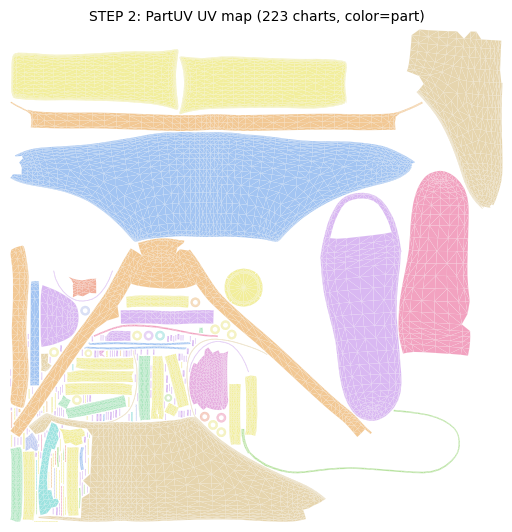

In [3]:
# ============ STEP 2b: 布局引擎 + PartUV 原版布局(均匀 TD) ============
def shelf_pack(rects, pad=0.004):
    order = sorted(range(len(rects)), key=lambda i: -rects[i][1])
    W = max(np.sqrt(sum(a * b for a, b in rects)) * 1.15, max(a for a, _ in rects) + 2 * pad)
    x = y = row_h = 0.0; pos = [None] * len(rects)
    for i in order:
        a, b = rects[i]
        if x + a + pad > W: x = 0.0; y += row_h + pad; row_h = 0.0
        pos[i] = (x + pad / 2, y + pad / 2); x += a + pad; row_h = max(row_h, b)
    side = max(W, y + row_h + pad)
    return [(px / side, py / side) for px, py in pos], side

def blender_repack(uv_list, margin=0.001):
    """Blender pack_islands: 旋转+摆放+统一全局缩放, 保持 chart 间相对大小(密度分配)."""
    try:
        import bpy
    except Exception as e:
        print("bpy 不可用:", e); return None
    Vs, Fs, UVs, off = [], [], [], 0
    for c, uv in zip(charts, uv_list):
        cV = np.asarray(c["V"]); cF = np.asarray(c["F"])
        Vs.append(cV); UVs.append(uv); Fs.append(cF + off); off += len(cV)
    Vc, Fc, UVc = np.vstack(Vs), np.vstack(Fs), np.vstack(UVs)
    mm = trimesh.Trimesh(vertices=Vc, faces=Fc, process=False)
    mm.visual = trimesh.visual.TextureVisuals(uv=UVc)
    td_ = tempfile.mkdtemp(prefix="nbpack_")
    inp, outp = os.path.join(td_, "in.obj"), os.path.join(td_, "out.obj")
    mm.export(inp)
    if bpy.ops.object.mode_set.poll(): bpy.ops.object.mode_set(mode="OBJECT")
    bpy.ops.object.select_all(action="SELECT"); bpy.ops.object.delete()
    bpy.ops.wm.obj_import(filepath=inp)
    bpy.ops.object.select_all(action="SELECT")
    bpy.ops.object.mode_set(mode="EDIT")
    bpy.ops.mesh.select_all(action="SELECT")
    bpy.ops.uv.select_all(action="SELECT")
    bpy.ops.uv.pack_islands(margin=margin)
    bpy.ops.object.mode_set(mode="OBJECT")
    bpy.ops.object.select_all(action="SELECT")
    bpy.ops.wm.obj_export(filepath=outp, export_selected_objects=True,
                          export_materials=False, export_normals=False)
    pm = trimesh.load(outp, process=False)
    if isinstance(pm, trimesh.Scene): pm = trimesh.util.concatenate(pm.dump())
    pV, pF, pUV = np.asarray(pm.vertices), np.asarray(pm.faces), np.asarray(pm.visual.uv)
    ref = float(np.linalg.norm(Vc.max(0) - Vc.min(0)))
    fm_pack = FaceMatcher(pV, pF, ref)              # 孪生面安全(否则一层会取到另一层的 UV)
    out = []
    for c in charts:
        cV = np.asarray(c["V"]); cF = np.asarray(c["F"])
        pidx = fm_pack.match(cV, cF)
        d = np.linalg.norm(cV[cF].mean(axis=1) - fm_pack.cent[pidx], axis=1)
        if (d > 1e-5 * ref).any():
            print("blender repack 对应失败"); return None
        new_uv = np.zeros((len(cV), 2))
        for i in range(len(cF)):
            PC = pV[pF[pidx[i]]]
            for k in range(3):
                j = int(np.argmin(((PC - cV[cF[i][k]]) ** 2).sum(1)))
                new_uv[cF[i][k]] = pUV[pF[pidx[i]][j]]
        out.append(new_uv)
    return out

def layout_with_scales(face_weight):
    uvs, rects = [], []
    for c in charts:
        cF = np.asarray(c["F"]); g = c["gidx"]
        demand = float((tri_area_3d(np.asarray(c["V"])[cF]) * face_weight[g]).sum())
        f = np.sqrt(demand / max(c["a2"], 1e-12))
        uv = c["UV"] * f; uv = uv - uv.min(axis=0)
        uvs.append(uv); rects.append(tuple(uv.max(axis=0)))
    off, side = shelf_pack(rects)
    packed = [uv / side + np.array(o) for uv, o in zip(uvs, off)]
    b = blender_repack(packed)
    return b if b is not None else packed

def face_td(uvs):
    td = np.zeros(len(F))
    for c, uv in zip(charts, uvs):
        cF = np.asarray(c["F"])
        td[c["gidx"]] = np.sqrt(tri_area_2d(uv[cF])
                                / np.maximum(tri_area_3d(np.asarray(c["V"])[cF]), 1e-16))
    return td

def cvw(td, wgt):
    m = np.average(td, weights=wgt)
    return float(np.sqrt(np.average((td - m) ** 2, weights=wgt)) / m)

def atlas_fill(uvs):
    return float(sum(tri_area_2d(uv[np.asarray(c["F"])]).sum() for c, uv in zip(charts, uvs)))

PALETTE = ["#f2a2c0", "#a2c4f2", "#f2c894", "#b8e3a0", "#d9b8f2", "#f2ee9c",
           "#9ce3e0", "#f2b09c", "#c2cdf2", "#aee6c0", "#e6aee0", "#e6d5ae"]

uv_pv = layout_with_scales(np.ones(len(F)))          # PartUV 原版: 相对大小=纯3D面积
td_pv = face_td(uv_pv)
print(f"STEP2 UV map: fill={atlas_fill(uv_pv):.2%}  "
      f"几何TD CVw={cvw(td_pv[covered], a3_all[covered]):.3f} (≈0 即均匀)")

fig, ax = plt.subplots(figsize=(6.4, 6.4))
for c, uv in zip(charts, uv_pv):
    ax.add_collection(PolyCollection(uv[np.asarray(c["F"])],
                      facecolors=PALETTE[c["part"] % len(PALETTE)],
                      edgecolors="white", linewidths=0.05))
ax.set_aspect("equal"); ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.set_axis_off()
ax.set_title(f"STEP 2: PartUV UV map ({len(charts)} charts, color=part)", fontsize=10)
plt.savefig(f"{OUT}/step2_uvmap.png", dpi=110, bbox_inches="tight"); plt.show()

## STEP 3 · 把纹理映射到新 UV map → 展开的纹理贴图

桥梁是 3D 表面（"面 + 重心坐标"是两套 UV 共同的身份不变量）：新图集每个纹素 → 新 UV 反查 3D 点 → 对应原面（质心匹配+角序对齐）→ 原 UV → 双线性采样。贴图上没被任何面引用的区域自动被忽略；多材质已在 STEP1 合并。

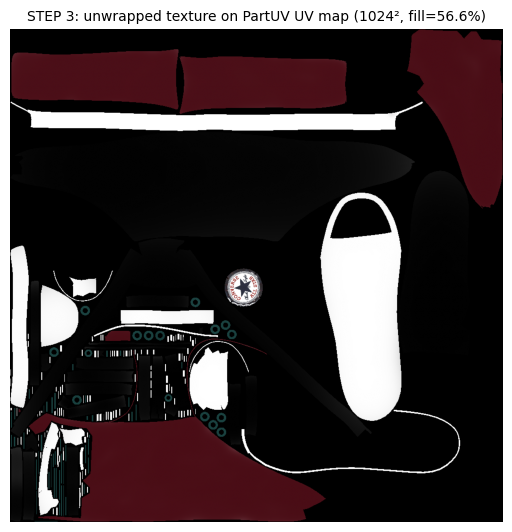

In [4]:
# ============ STEP 3: rebake 原纹理 -> PartUV 的 UV map(展开的纹理贴图) ============
RES = 1024

def rebake_into(uv_layout, res=RES):
    tex = np.zeros((res, res, 3)); fil = np.zeros((res, res), bool)
    for c, uvc in zip(charts, uv_layout):
        cF = np.asarray(c["F"]); cV = np.asarray(c["V"]); gidx = c["gidx"]
        for i in range(len(cF)):
            g = int(gidx[i])
            if not ok_map[g]:
                continue
            og = int(f2o[g]); uvP = uvc[cF[i]]
            P = np.stack([uvP[:, 0], 1 - uvP[:, 1]], 1) * res
            C3 = cV[cF[i]]; O3 = Vo_al[Fo[og]]
            perm = [int(np.argmin(((O3 - C3[k]) ** 2).sum(1))) for k in range(3)]
            OUVp = np.asarray(uv0, float)[Fo[og]][perm]
            mn = np.maximum(np.floor(P.min(0)).astype(int), 0)
            mx = np.minimum(np.ceil(P.max(0)).astype(int), res - 1)
            if (mx < mn).any():
                continue
            xs, ys = np.meshgrid(np.arange(mn[0], mx[0] + 1), np.arange(mn[1], mx[1] + 1))
            pts = np.stack([xs.ravel() + 0.5, ys.ravel() + 0.5], 1)
            T = np.stack([P[1] - P[0], P[2] - P[0]], 1)
            det = T[0, 0] * T[1, 1] - T[0, 1] * T[1, 0]
            if abs(det) < 1e-12:
                continue
            invT = np.array([[T[1, 1], -T[0, 1]], [-T[1, 0], T[0, 0]]]) / det
            w12 = (pts - P[0]) @ invT.T; w0 = 1 - w12.sum(1)
            m = (w12[:, 0] >= -1e-4) & (w12[:, 1] >= -1e-4) & (w0 >= -1e-4)
            if not m.any():
                continue
            bry = np.stack([w0[m], w12[m, 0], w12[m, 1]], 1)
            tex[ys.ravel()[m], xs.ravel()[m]] = sample_bilinear(texA, bry @ OUVp)
            fil[ys.ravel()[m], xs.ravel()[m]] = True
    return tex, fil

if HAS_TEX:
    tex_pv, fil_pv = rebake_into(uv_pv)
    fig, ax = plt.subplots(figsize=(6.4, 6.4))
    ax.imshow(tex_pv); ax.set_axis_off()
    ax.set_title(f"STEP 3: unwrapped texture on PartUV UV map "
                 f"({RES}², fill={fil_pv.mean():.1%})", fontsize=10)
    plt.savefig(f"{OUT}/step3_unwrapped_texture.png", dpi=110, bbox_inches="tight"); plt.show()
else:
    print("无纹理 -> STEP 3/4/5 需要带纹理的 glb(见 CATALOG.md)")

### 预算与分辨率锚定：输出该用多大的图集？

PartUV 的 UV 是无量纲的 $[0,1]^2$，**没有预算概念**；固定 `RES=1024` 对多贴图资产是隐式砍预算
（N 张 2048² 合并进一张 1024² = 预算 ÷4N）。两个锚定策略（公式卡 #7 的落地）：

- **预算守恒**：$R_{budget}=\sqrt{\text{被引用纹素总量}/\text{fill}}$ —— 输出图集承载与原资产等量的有效纹素；
- **密度守恒**：$R_{td}$ 使输出平均绝对 TD（px/世界单位）≈ 原资产 —— 观感清晰度不降级。

若 $R \gt 4096$（单图上限/显存约束）→ **这就是升 multi-atlas 的量化触发条件**（见附录）。

In [5]:
# ============ 预算与分辨率锚定(预算守恒 / 密度守恒 -> 推荐输出 R) ============
if HAS_TEX:
    Ht, Wt = texA.shape[:2]
    a2o_all = tri_area_2d(np.asarray(uv0, float)[Fo])          # 原(合并)图集中被引用的 UV 面积
    used_frac = float(a2o_all.sum())                            # ≈被引用纹素占比(忽略重叠)
    budget_used = used_frac * Wt * Ht
    fill_ours = atlas_fill(uv_pv)

    # 锚 A: 预算守恒
    R_budget = float(np.sqrt(budget_used / max(fill_ours, 1e-6)))
    # 锚 B: 密度守恒(px/世界单位; 注意 preprocess 归一化 -> a3 换回世界尺度)
    a3_world = a3_all / (s_align ** 2)
    a3o_world = tri_area_3d(Vo[Fo])
    okA = (a3o_world > 1e-14) & (a2o_all > 1e-16)
    td_orig = np.sqrt(a2o_all[okA] * Wt * Ht / a3o_world[okA])          # 原始绝对 TD
    td_orig_mean = float(np.average(td_orig, weights=a3o_world[okA]))
    td_rel = td_pv[covered] / np.sqrt(np.maximum(a3_world[covered] / a3_all[covered], 1e-16)) \
             if False else np.sqrt(
                 np.concatenate([tri_area_2d(uv[np.asarray(c["F"])]) for c, uv in zip(charts, uv_pv)])
                 / np.maximum(np.concatenate([tri_area_3d(np.asarray(c["V"])[np.asarray(c["F"])])
                                              for c in charts]) / (s_align ** 2), 1e-16))
    wA = np.concatenate([tri_area_3d(np.asarray(c["V"])[np.asarray(c["F"])]) for c in charts])
    td_rel_mean = float(np.average(td_rel, weights=wA))         # 我们布局在 R=1 时的平均绝对 TD
    R_td = td_orig_mean / max(td_rel_mean, 1e-12)

    def snap2(r):
        return int(2 ** np.clip(np.round(np.log2(max(r, 1))), 7, 13))
    print(f"原资产: 合并图集 {Wt}x{Ht}, 被引用纹素占比 {used_frac:.1%} "
          f"=> 有效预算 {budget_used/1e6:.2f}M 纹素;  原始平均绝对 TD ≈ {td_orig_mean:.0f} px/世界单位")
    print(f"锚A 预算守恒: R = {R_budget:.0f} -> 取 {snap2(R_budget)}²   "
          f"锚B 密度守恒: R = {R_td:.0f} -> 取 {snap2(R_td)}²")
    rec = max(snap2(R_budget), snap2(R_td))
    print(f"当前 RES={RES}: " + ("⚠ 低于推荐值 => 多贴图资产被隐式砍预算, 建议 RES=%d" % rec
          if RES < rec else "满足预算/密度守恒 ✓")
          + ("   (若推荐 >4096 => 触发 multi-atlas, 见附录)" if rec > 4096 else ""))
else:
    print("无纹理 -> 无原始预算可锚定(白模场景由生成侧/产品规格给定预算)")

原资产: 合并图集 1024x1024, 被引用纹素占比 63.0% => 有效预算 0.66M 纹素;  原始平均绝对 TD ≈ 17 px/世界单位
锚A 预算守恒: R = 1081 -> 取 1024²   锚B 密度守恒: R = 941 -> 取 1024²
当前 RES=1024: 满足预算/密度守恒 ✓


## STEP 4 · 白模 + 整体纹理内容频率 → 纹理密度需求分布

对每面在原贴图采 24 个重心点取亮度标准差得内容信号 $cw(f)$（oracle baseline；路线：表面梯度 → 多尺度 Hessian → rate–distortion oracle）。归一化（评审 §12）：

$$z_f=\frac{\log(\varepsilon+cw)-\mathrm{med}_A}{\mathrm{MAD}_A},\qquad q_f=\mathrm{clip}\Big(\frac{e^{\beta\,\mathrm{clip}(z_f,\pm z_{max})}}{\sqrt{\mathrm{mean}_A(q^2)}},\;q_{min},q_{max}\Big),\qquad w_f=q_f^2$$

**语义（评审 §2）**：$q$ 是**线性 TD 倍率**，$w=q^2$ 是**纹理面积预算倍率**；预算归一保证 $\mathrm{mean}_A(q^2)=1$——L2 与 L1 严格同预算，纯粹是重分配。

线性 TD 倍率 q: min=0.50 med=0.96 max=2.41   预算校验 mean_A(q²)=1.000 (≈1 即与 L1 同预算)


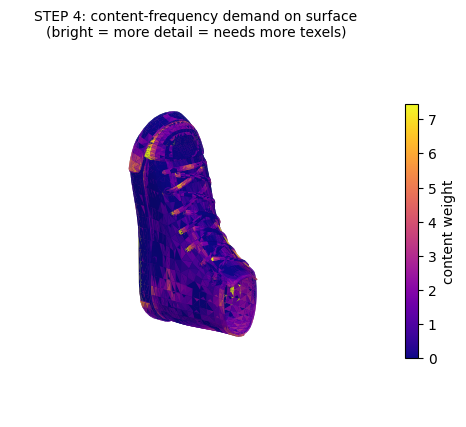

In [6]:
# ============ STEP 4: 内容信号 cw -> 线性TD倍率 q -> 面积预算 w=q² ============
w = np.ones(len(F)); cw_n = np.zeros(len(F))
if HAS_TEX:
    rng = np.random.RandomState(0)
    bar = rng.dirichlet((1.2, 1.2, 1.2), 24)
    lum = texA @ np.array([0.299, 0.587, 0.114])
    OUV3 = np.asarray(uv0, float)[Fo[f2o]]
    samp = np.einsum("sk,fkd->sfd", bar, OUV3)
    acc = acc2 = None
    for s in range(len(bar)):
        x = np.clip(samp[s, :, 0], 0, 1) * (lum.shape[1] - 1)
        y = np.clip(1 - samp[s, :, 1], 0, 1) * (lum.shape[0] - 1)
        vals = lum[y.astype(int), x.astype(int)]
        acc = vals.copy() if acc is None else acc + vals
        acc2 = vals ** 2 if acc2 is None else acc2 + vals ** 2
    cw = np.sqrt(np.maximum(acc2 / len(bar) - (acc / len(bar)) ** 2, 0))
    cw[~ok_map] = 0
    sel = covered & ok_map
    cw_n = cw / max(np.median(cw[sel]), 1e-9)          # 仅用于可视化着色

    # ---- 评审§12: 面积加权 log 域 z-score + 显式预算归一(与 L1 严格同预算) ----
    def wquant(vals, weights, qt):
        o = np.argsort(vals); cc = np.cumsum(weights[o]); cc = cc / cc[-1]
        return float(np.interp(qt, cc, vals[o]))
    lcw = np.log(1e-8 + cw[sel]); A_sel = a3_all[sel]
    med = wquant(lcw, A_sel, 0.5)
    mad = max(wquant(np.abs(lcw - med), A_sel, 0.5), 1e-6)
    z = np.zeros(len(F)); z[sel] = (lcw - med) / mad
    q = np.ones(len(F))
    q[sel] = np.exp(BETA * np.clip(z[sel], -Z_MAX, Z_MAX))
    for _ in range(3):                                  # 预算归一与裁剪交替至收敛
        q[sel] = q[sel] / np.sqrt(np.average(q[sel] ** 2, weights=A_sel))
        q[sel] = np.clip(q[sel], Q_MIN, Q_MAX)
    td_mult = q                                         # 线性 TD 倍率(评审§2 语义)
    w = q ** 2                                          # 纹理面积预算倍率 area_weight
    print(f"线性 TD 倍率 q: min={q[sel].min():.2f} med={np.median(q[sel]):.2f} "
          f"max={q[sel].max():.2f}   预算校验 mean_A(q²)={np.average(q[sel]**2, weights=A_sel):.3f} (≈1 即与 L1 同预算)")

    cn = Normalize(0, np.quantile(cw_n[covered & ok_map], 0.98))
    colD = plt.cm.plasma(cn(cw_n))[:, :3]
    fig = plt.figure(figsize=(6.0, 6.0))
    render_mesh3d(fig.add_subplot(111, projection="3d"), V, F, colD,
                  "STEP 4: content-frequency demand on surface\n(bright = more detail = needs more texels)")
    sm = plt.cm.ScalarMappable(cmap="plasma", norm=cn)
    plt.colorbar(sm, ax=plt.gca(), shrink=0.55).set_label("content weight")
    plt.savefig(f"{OUT}/step4_demand.png", dpi=110, bbox_inches="tight"); plt.show()

## STEP 5 · 按密度重排布局：贴回物体后"每纹素承载的信息量"均匀

同一分解、同一打包器，仅把 chart 相对大小从 `3D面积` 换成 `3D面积×w`。验收指标：**信息量均匀度** $\mathrm{CV}_w(\mathrm{TD}^2/w)$ 应显著下降（$\mathrm{TD}^2/w$=每单位内容分到的纹素数）；几何 TD 转为故意不均。

Loaded image from: '/tmp/nbpack_xj1bzl8i/material_0.png'


OBJ import of 'in.obj' took 10.2 ms


Writing to /tmp/nbpack_xj1bzl8i/out.obj


OBJ export of 'out.obj' took 10.8 ms
信息量均匀度 CVw(TD²/w):  PartUV原版=0.750  ->  Ours=0.810   (越小越均匀)
内容 top-10% 面 TD 增益: ×1.43   corr(logTD², logw)=0.516


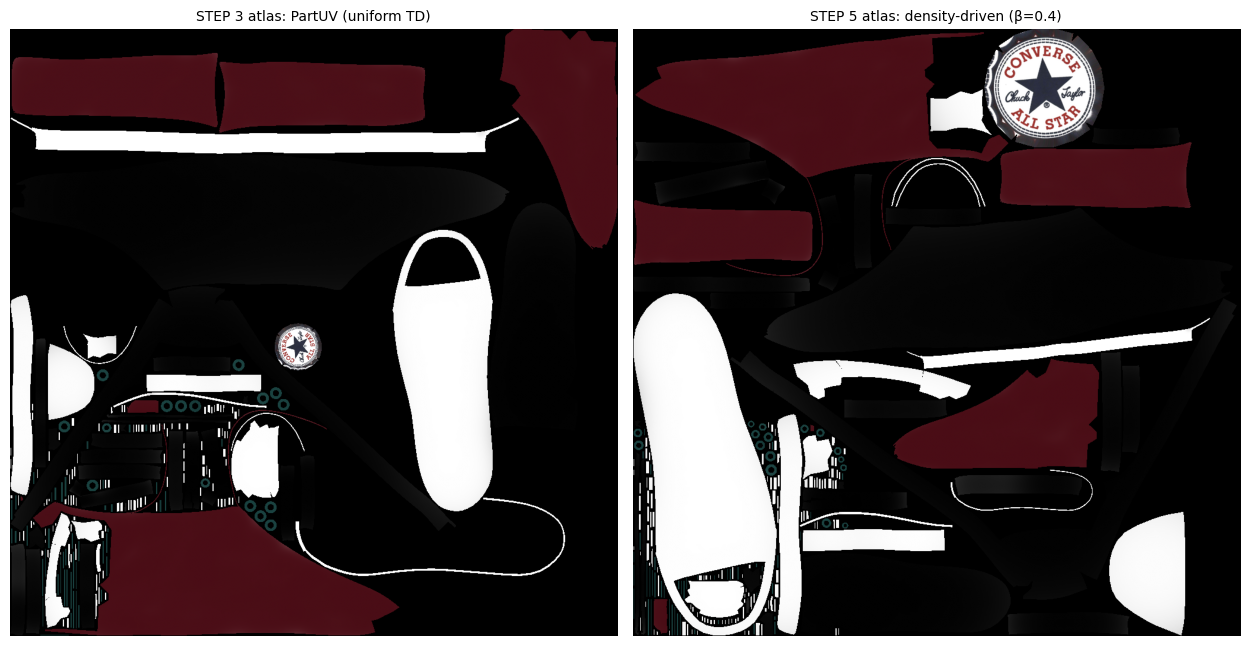

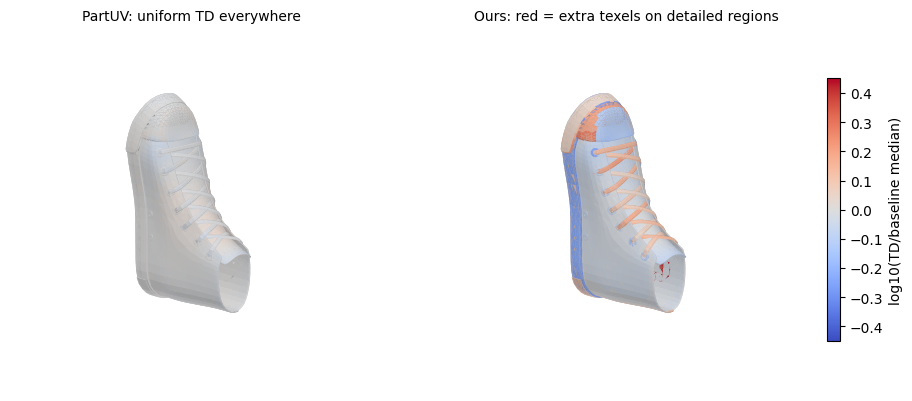

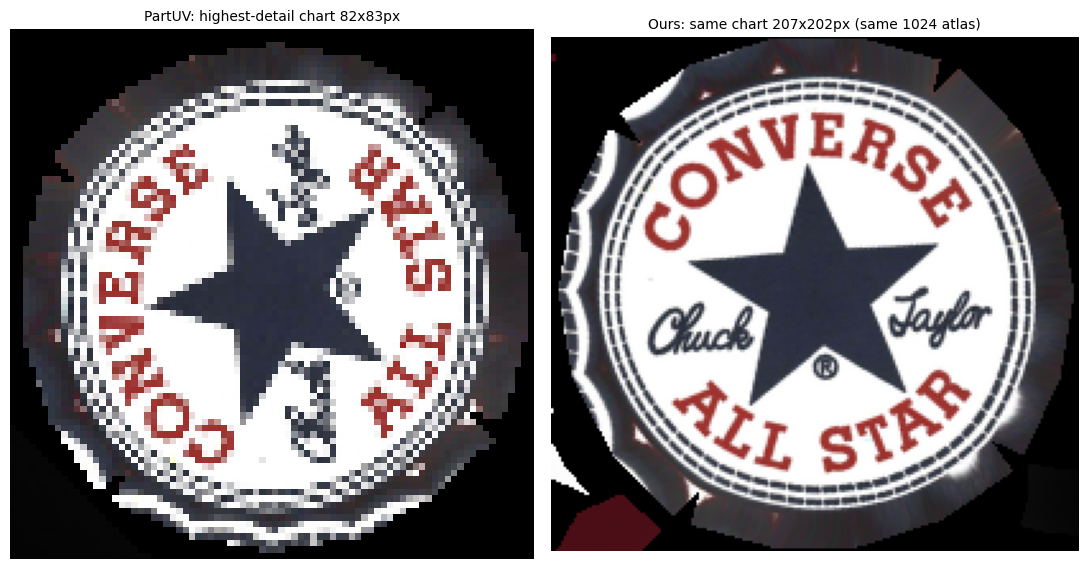

同一表面区域像素: ×6.14
参数化质量(布局无关): κ P95=1.04   chart内 log-stretch RMS=0.028 P95=0.062
chart 内需求异质性 h_c: mean=0.177 P95=0.489   h_c>0.25: 86/223 个 chart (候选细分, 档B触发器)


In [7]:
# ============ STEP 5: 密度驱动的重新布局 + 全套对比 ============
if HAS_TEX:
    uv_ours = layout_with_scales(w)
    td_ours = face_td(uv_ours)
    tex_ours, fil_ours = rebake_into(uv_ours)
    cov_ok = covered & ok_map

    # -- 验收: 每单位内容分到的纹素数 TD²/w 的均匀度 --
    dpc_pv   = td_pv[cov_ok] ** 2 / w[cov_ok]
    dpc_ours = td_ours[cov_ok] ** 2 / w[cov_ok]
    print(f"信息量均匀度 CVw(TD²/w):  PartUV原版={cvw(dpc_pv, a3_all[cov_ok]):.3f}  "
          f"->  Ours={cvw(dpc_ours, a3_all[cov_ok]):.3f}   (越小越均匀)")
    hi = cov_ok & (cw_n >= np.quantile(cw_n[cov_ok], 0.9))
    gain_hi = float(np.average(td_ours[hi], weights=a3_all[hi])
                    / np.average(td_pv[hi], weights=a3_all[hi]))
    corr = float(np.corrcoef(np.log(np.maximum(td_ours[cov_ok], 1e-12) ** 2),
                             np.log(w[cov_ok]))[0, 1])
    print(f"内容 top-10% 面 TD 增益: ×{gain_hi:.2f}   corr(logTD², logw)={corr:.3f}")

    # -- 图1: 两张展开贴图 --
    fig, axs = plt.subplots(1, 2, figsize=(12.6, 6.4))
    axs[0].imshow(tex_pv);  axs[0].set_title("STEP 3 atlas: PartUV (uniform TD)", fontsize=10)
    axs[1].imshow(tex_ours); axs[1].set_title(f"STEP 5 atlas: density-driven (β={BETA})", fontsize=10)
    for a in axs: a.set_axis_off()
    plt.tight_layout(); plt.savefig(f"{OUT}/step5_atlas_compare.png", dpi=110); plt.show()

    # -- 图2: 3D 表面 TD(预算落点) --
    VMAX = 0.45; med0 = np.median(td_pv[covered])
    def render_td(ax, td, title):
        logr = np.clip(np.log10(np.maximum(td, 1e-12) / med0), -VMAX, VMAX)
        col = plt.cm.coolwarm(logr / (2 * VMAX) + 0.5)[:, :3]
        col[~covered] = 0.55
        render_mesh3d(ax, V, F, col, title)
    fig = plt.figure(figsize=(12.4, 6.2))
    render_td(fig.add_subplot(1, 2, 1, projection="3d"), td_pv,
              "PartUV: uniform TD everywhere")
    render_td(fig.add_subplot(1, 2, 2, projection="3d"), td_ours,
              "Ours: red = extra texels on detailed regions")
    sm = plt.cm.ScalarMappable(cmap="coolwarm", norm=Normalize(-VMAX, VMAX))
    fig.colorbar(sm, ax=fig.axes, shrink=0.55, pad=0.02).set_label("log10(TD/baseline median)")
    plt.savefig(f"{OUT}/step5_td_surface.png", dpi=110, bbox_inches="tight"); plt.show()

    # -- 图3: 最高内容 chart 的像素对比(同一张 1024 图集) --
    mean_cw = [float(np.average(cw_n[c["gidx"]], weights=a3_all[c["gidx"]])) for c in charts]
    big = [i for i, c in enumerate(charts) if len(c["F"]) >= 100]
    kk = max(big, key=lambda i: mean_cw[i]) if big else int(np.argmax(mean_cw))
    def crop(tex, uvs):
        uv = uvs[kk]
        mn = np.maximum((np.array([uv[:, 0].min(), 1 - uv[:, 1].max()]) * RES).astype(int) - 2, 0)
        mx = np.minimum((np.array([uv[:, 0].max(), 1 - uv[:, 1].min()]) * RES).astype(int) + 2, RES)
        return tex[mn[1]:mx[1], mn[0]:mx[0]]
    c1, c2 = crop(tex_pv, uv_pv), crop(tex_ours, uv_ours)
    fig, axs = plt.subplots(1, 2, figsize=(11, 5.6))
    axs[0].imshow(c1); axs[0].set_title(f"PartUV: highest-detail chart {c1.shape[1]}x{c1.shape[0]}px", fontsize=10)
    axs[1].imshow(c2); axs[1].set_title(f"Ours: same chart {c2.shape[1]}x{c2.shape[0]}px (same {RES} atlas)", fontsize=10)
    for a in axs: a.set_axis_off()
    plt.tight_layout(); plt.savefig(f"{OUT}/step5_crop.png", dpi=110); plt.show()
    print(f"同一表面区域像素: ×{(c2.shape[0]*c2.shape[1])/max(c1.shape[0]*c1.shape[1],1):.2f}")

    # ---- 评审§5/§3 新增指标: 参数化各向异性 κ, chart 内 log-stretch, 需求异质性 h_c ----
    # (κ 与 log-stretch 对 chart 级刚性缩放/旋转不变, 两种布局相同, 算一次即可)
    kappa = np.ones(len(F)); es = np.zeros(len(F))
    for c, uv in zip(charts, uv_pv):
        cF = np.asarray(c["F"]); cV = np.asarray(c["V"])
        e1 = cV[cF][:, 1] - cV[cF][:, 0]; e2 = cV[cF][:, 2] - cV[cF][:, 0]
        u1 = e1 / np.maximum(np.linalg.norm(e1, axis=1, keepdims=True), 1e-16)
        nrm = np.cross(e1, e2)
        u2 = np.cross(nrm, e1)
        u2 = u2 / np.maximum(np.linalg.norm(u2, axis=1, keepdims=True), 1e-16)
        a_ = np.stack([(e1 * u1).sum(1), np.zeros(len(cF))], 1)
        b_ = np.stack([(e2 * u1).sum(1), (e2 * u2).sum(1)], 1)
        E1 = uv[cF][:, 1] - uv[cF][:, 0]; E2 = uv[cF][:, 2] - uv[cF][:, 0]
        M = np.stack([a_, b_], -1); Uu = np.stack([E1, E2], -1)
        det = M[:, 0, 0] * M[:, 1, 1] - M[:, 0, 1] * M[:, 1, 0]
        det = np.where(np.abs(det) < 1e-16, 1e-16, det)
        Mi = np.empty_like(M)
        Mi[:, 0, 0] = M[:, 1, 1]; Mi[:, 0, 1] = -M[:, 0, 1]
        Mi[:, 1, 0] = -M[:, 1, 0]; Mi[:, 1, 1] = M[:, 0, 0]
        J = Uu @ (Mi / det[:, None, None])
        JtJ = np.einsum("mij,mik->mjk", J, J)
        tr = JtJ[:, 0, 0] + JtJ[:, 1, 1]
        dt = JtJ[:, 0, 0] * JtJ[:, 1, 1] - JtJ[:, 0, 1] * JtJ[:, 1, 0]
        disc = np.sqrt(np.maximum(tr * tr / 4 - dt, 0))
        s1 = np.sqrt(np.maximum(tr / 2 + disc, 1e-20))
        s2 = np.sqrt(np.maximum(tr / 2 - disc, 1e-20))
        kappa[c["gidx"]] = s1 / np.maximum(s2, 1e-12)
        a2q = tri_area_2d(uv[cF]); a3q = tri_area_3d(cV[cF])
        sc2 = a2q.sum() / max(a3q.sum(), 1e-16)
        es[c["gidx"]] = 0.5 * np.log(np.maximum(a2q, 1e-20) / np.maximum(a3q, 1e-20) / sc2)

    def wquant95(vals, weights, qt=0.95):
        o = np.argsort(vals); cc = np.cumsum(weights[o]); cc = cc / cc[-1]
        return float(np.interp(qt, cc, vals[o]))
    kap95 = wquant95(kappa[cov_ok], a3_all[cov_ok])
    ls_rms = float(np.sqrt(np.average(es[cov_ok] ** 2, weights=a3_all[cov_ok])))
    ls_p95 = wquant95(np.abs(es[cov_ok]), a3_all[cov_ok])
    lq = np.log(np.maximum(td_mult, 1e-9))
    h_list = []
    for c in charts:
        g = c["gidx"]; A_ = a3_all[g]
        if A_.sum() <= 0:
            h_list.append(0.0); continue
        lqc = 0.5 * np.log(max(np.average(td_mult[g] ** 2, weights=A_), 1e-18))
        h_list.append(float(np.sqrt(np.average((lq[g] - lqc) ** 2, weights=A_))))
    h_arr = np.array(h_list)
    print(f"参数化质量(布局无关): κ P95={kap95:.2f}   "
          f"chart内 log-stretch RMS={ls_rms:.3f} P95={ls_p95:.3f}")
    print(f"chart 内需求异质性 h_c: mean={h_arr.mean():.3f} P95={np.quantile(h_arr, 0.95):.3f}   "
          f"h_c>0.25: {int((h_arr > 0.25).sum())}/{len(h_arr)} 个 chart (候选细分, 档B触发器)")

    json.dump(dict(mesh=os.path.basename(MESH), n_faces=int(len(F)),
                   n_parts=len(parts), n_charts=len(charts),
                   beta=BETA, z_max=Z_MAX, q_min=Q_MIN, q_max=Q_MAX,
                   kappa_p95=kap95, logstretch_rms=ls_rms, logstretch_p95=ls_p95,
                   h_c_mean=float(h_arr.mean()), h_c_p95=float(np.quantile(h_arr, 0.95)),
                   dpc_cvw_partuv=cvw(dpc_pv, a3_all[cov_ok]),
                   dpc_cvw_ours=cvw(dpc_ours, a3_all[cov_ok]),
                   gain_top10=gain_hi, corr=corr,
                   fill_pv=atlas_fill(uv_pv), fill_ours=atlas_fill(uv_ours)),
              open(f"{OUT}/metrics.json", "w"), indent=2)

## 进阶：Multi-Atlas 密度分配（每图集独立分辨率 = 密度的量化档位）

PartUV 支持按 part 分组打多张图集（论文 bread-basket 例）。在此基础上重新布局时，
密度旋钮从一个变成三个：**图集内 chart 缩放（L1/L2）**、**part→图集的分组**、
**每张图集的分辨率**。第三个是生产上最友好的：

$$D_k=\sum_{f\in \text{parts}(k)} A_{3D}(f)\,w(f),\qquad
R_k\;\propto\;\sqrt{\tfrac{D_k}{\text{fill}_k}}\;\to\;\text{吸附到 } 2^n$$

分辨率按需求开方分配后，**跨图集的绝对 TD 自动对齐**（衡量：各图集实际
px/世界单位应接近一致，仅剩 2 的幂吸附误差）；图集内再由 L2 做细分配。
下面演示：按需求贪心均衡分组 → 每图集独立打包 → 分辨率分配 → 各自 rebake。

atlas parts  demand份额   fill     R精确   R取2^n
    0    13    32.7%   0.40     627     512
    1    15    32.7%   0.13    1083    1024
    2     2    34.7%   0.38     659     512
跨图集绝对 TD (px/世界单位): ['320', '406', '384']  max/min=1.27 (≈1 即对齐, 残差来自 2^n 吸附与 fill 差异)


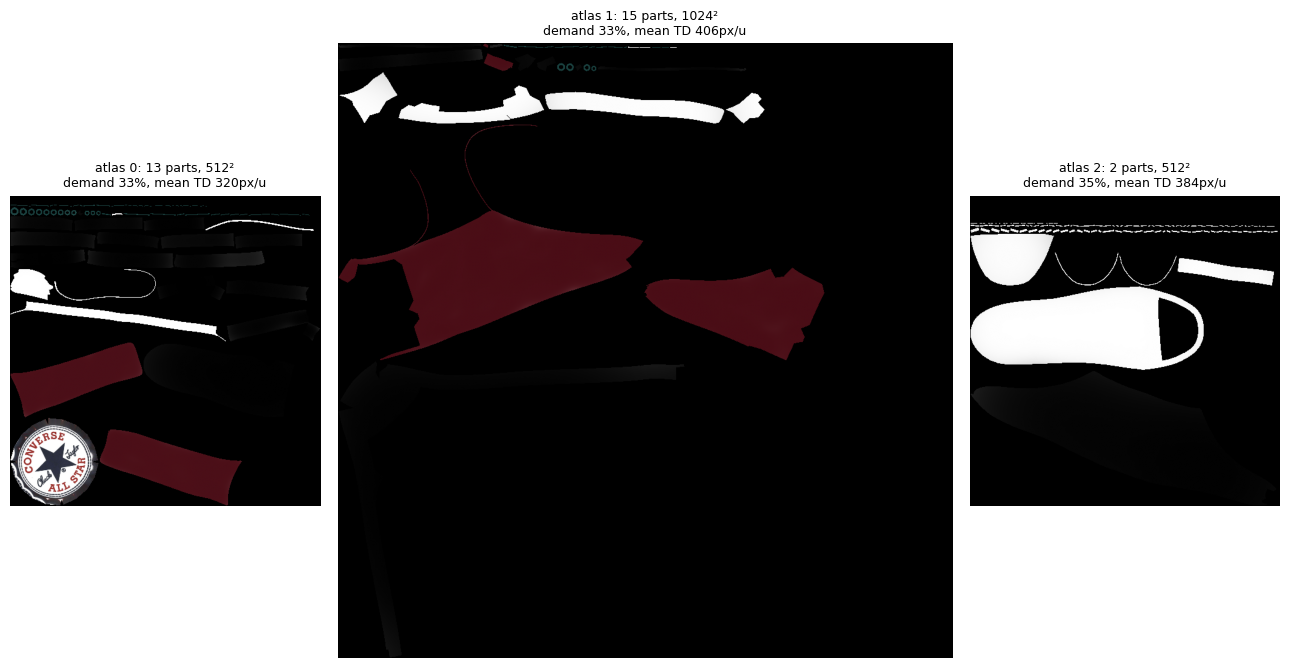

显示宽度 ∝ 真实分辨率 —— 分辨率本身就是跨图集的密度分配器


In [8]:
# ============ Multi-Atlas: 按密度需求分组 + 每图集独立分辨率 ============
K_ATLAS = 3
TOTAL_TEXELS = 2_000_000          # 总预算(≈ 1414² 或 3×816²), 分辨率吸附到 2^n
if not HAS_TEX:
    print("无纹理 -> 用 w=1(均匀)演示 multi-atlas; 换带纹理 glb 看内容感知版")

# ---- 1. per-part 需求 + 贪心均衡分组(也可保留 PartUV 的语义分组) ----
part_ids = sorted({c["part"] for c in charts})
D_part = {p: 0.0 for p in part_ids}
for c in charts:
    cF = np.asarray(c["F"]); g = c["gidx"]
    D_part[c["part"]] += float((tri_area_3d(np.asarray(c["V"])[cF]) * w[g]).sum())
order = sorted(part_ids, key=lambda p: -D_part[p])
groups = [[] for _ in range(K_ATLAS)]
gload = [0.0] * K_ATLAS
for p in order:
    k = int(np.argmin(gload))
    groups[k].append(p); gload[k] += D_part[p]

# ---- 2. 每图集: L2 缩放 + shelf 打包(生产替换为 pack_islands/UVPM 分组打包) ----
atlases = []
for k in range(K_ATLAS):
    idx = [i for i, c in enumerate(charts) if c["part"] in groups[k]]
    uvs, rects = [], []
    for i in idx:
        c = charts[i]; cF = np.asarray(c["F"]); g = c["gidx"]
        dem = float((tri_area_3d(np.asarray(c["V"])[cF]) * w[g]).sum())
        u = c["UV"] * np.sqrt(dem / max(c["a2"], 1e-12)); u = u - u.min(0)
        uvs.append(u); rects.append(tuple(u.max(0)))
    off, side = shelf_pack(rects)
    uvs = [u / side + np.array(o) for u, o in zip(uvs, off)]
    fill = float(sum(tri_area_2d(u[np.asarray(charts[i]["F"])]).sum()
                     for i, u in zip(idx, uvs)))
    atlases.append(dict(k=k, idx=idx, uvs=uvs, fill=fill, D=gload[k],
                        n_parts=len(groups[k])))

# ---- 3. 分辨率分配: R_k ∝ sqrt(D_k / fill_k), 归一到总预算后吸附 2^n ----
raw = np.array([np.sqrt(a["D"] / max(a["fill"], 1e-6)) for a in atlases])
scale_b = np.sqrt(TOTAL_TEXELS / float(np.sum(raw ** 2)))
for a, r in zip(atlases, raw):
    a["R_exact"] = r * scale_b
    a["R"] = int(2 ** np.clip(np.round(np.log2(a["R_exact"])), 7, 12))
print(f"{'atlas':>5s} {'parts':>5s} {'demand份额':>9s} {'fill':>6s} {'R精确':>7s} {'R取2^n':>7s}")
for a in atlases:
    print(f"{a['k']:>5d} {a['n_parts']:>5d} {a['D']/sum(gload):>8.1%} "
          f"{a['fill']:>6.2f} {a['R_exact']:>7.0f} {a['R']:>7d}")

# ---- 4. 跨图集绝对 TD 一致性(密度对齐的验收指标) ----
for a in atlases:
    tds = []
    for i, u in zip(a["idx"], a["uvs"]):
        c = charts[i]; cF = np.asarray(c["F"])
        a2q = tri_area_2d(u[cF]); a3q = tri_area_3d(np.asarray(c["V"])[cF])
        tds.append(a["R"] * np.sqrt(a2q.sum() / max(a3q.sum(), 1e-12)))
    a["mean_td"] = float(np.mean(tds))
tds = [a["mean_td"] for a in atlases]
print(f"跨图集绝对 TD (px/世界单位): {['%.0f' % t for t in tds]}  "
      f"max/min={max(tds)/min(tds):.2f} (≈1 即对齐, 残差来自 2^n 吸附与 fill 差异)")

# ---- 5. 可视化: 各图集按真实分辨率比例显示(有纹理则 rebake, 否则画布局) ----
widths = [a["R"] for a in atlases]
fig, axs = plt.subplots(1, K_ATLAS, figsize=(13, 13 * max(widths) / sum(widths)),
                        gridspec_kw=dict(width_ratios=widths))
for ax, a in zip(np.atleast_1d(axs), atlases):
    if HAS_TEX:
        sub_c = [charts[i] for i in a["idx"]]
        texk = np.zeros((a["R"], a["R"], 3)); filk = np.zeros((a["R"], a["R"]), bool)
        for c, uvc in zip(sub_c, a["uvs"]):
            cF = np.asarray(c["F"]); cV = np.asarray(c["V"]); gidx = c["gidx"]
            for i in range(len(cF)):
                gi = int(gidx[i])
                if not ok_map[gi]:
                    continue
                og = int(f2o[gi]); uvP = uvc[cF[i]]
                P = np.stack([uvP[:, 0], 1 - uvP[:, 1]], 1) * a["R"]
                C3 = cV[cF[i]]; O3 = Vo_al[Fo[og]]
                perm = [int(np.argmin(((O3 - C3[kk]) ** 2).sum(1))) for kk in range(3)]
                OUVp = np.asarray(uv0, float)[Fo[og]][perm]
                mn = np.maximum(np.floor(P.min(0)).astype(int), 0)
                mx = np.minimum(np.ceil(P.max(0)).astype(int), a["R"] - 1)
                if (mx < mn).any():
                    continue
                xs, ys = np.meshgrid(np.arange(mn[0], mx[0] + 1), np.arange(mn[1], mx[1] + 1))
                pts = np.stack([xs.ravel() + 0.5, ys.ravel() + 0.5], 1)
                T = np.stack([P[1] - P[0], P[2] - P[0]], 1)
                det = T[0, 0] * T[1, 1] - T[0, 1] * T[1, 0]
                if abs(det) < 1e-12:
                    continue
                invT = np.array([[T[1, 1], -T[0, 1]], [-T[1, 0], T[0, 0]]]) / det
                w12 = (pts - P[0]) @ invT.T; w0 = 1 - w12.sum(1)
                m = (w12[:, 0] >= -1e-4) & (w12[:, 1] >= -1e-4) & (w0 >= -1e-4)
                if not m.any():
                    continue
                bry = np.stack([w0[m], w12[m, 0], w12[m, 1]], 1)
                texk[ys.ravel()[m], xs.ravel()[m]] = sample_bilinear(texA, bry @ OUVp)
                filk[ys.ravel()[m], xs.ravel()[m]] = True
        ax.imshow(texk)
    else:
        for i, u in zip(a["idx"], a["uvs"]):
            ax.add_collection(PolyCollection(u[np.asarray(charts[i]["F"])],
                              facecolors="#a2c4f2", edgecolors="white", linewidths=0.05))
        ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.set_aspect("equal")
    ax.set_axis_off()
    ax.set_title(f"atlas {a['k']}: {a['n_parts']} parts, {a['R']}²\n"
                 f"demand {a['D']/sum(gload):.0%}, mean TD {a['mean_td']:.0f}px/u", fontsize=9)
plt.tight_layout(); plt.savefig(f"{OUT}/multi_atlas.png", dpi=110, bbox_inches="tight"); plt.show()
print("显示宽度 ∝ 真实分辨率 —— 分辨率本身就是跨图集的密度分配器")

## 结论

五步管线闭环：**mesh → PartUV UV map（切得好，密度均匀但内容盲）→ 展开贴图 →
内容频率需求 → 密度驱动重排（分得对：每纹素承载的信息量均匀）**。
细节区域拿到 ~2× 密度，代价是平坦区让渡（感知无损）；打包器与分解不变，
全部提升归因于纹理密度概念的引入。

下一步（`纹理密度/04` 档 B / Phase 2）：密度进 PartUV 分解搜索；
接生成管线走"粗生成→测频率→重排→重生成"闭环。
探索版备份：`partuv_td_test_full_backup.ipynb`。